In [2]:
from __future__ import annotations
from typing import TYPE_CHECKING

import librosa
import polars as pl
import numpy as np
import subprocess
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

from modules.preprocessing.audio_process import *
from modules.preprocessing.dataframe_process import filter_coughvid_df

if TYPE_CHECKING:
    import numpy.typing as npt 

In [3]:
df: pl.DataFrame = filter_coughvid_df(
    pl.read_csv(
        'data/tabular_form/tabular_form/coughvid_v3.csv', 
        schema_overrides={
            "age":pl.Float32
        }
    )
)

In [4]:
dir: Path = Path("data/public_dataset_v3_wav")

def get_audio_duration_fast(file_path: Path, sr: int = 16_000) -> list[float] | float:
    wave, rate = librosa.load(file_path, sr=sr)
    waves,  _ = segment_cough(wave, rate, cough_padding=0.1, min_cough_len=0.1)
    
    if len(waves) == 1:
        return (waves[0].size / (waves[0].ndim if waves[0].ndim > 1 else 1)) / rate
    
    try:
        return [
            (wave.size / (wave.ndim if wave.ndim > 1 else 1)) / rate
            for wave in waves
        ]
    except Exception as e:
        print(waves, len(waves), rate)
        raise e

In [5]:
files: map = map(lambda f: dir/f"{f.split(".")[0]}.wav",  df["audio_name"].to_list())

results: npt.NDArray = np.hstack([
    get_audio_duration_fast(file) for file in files
])

In [28]:
results

array([inf, inf, inf, ..., inf, inf, inf], shape=(30908,))

In [6]:

target_len_95 = np.percentile(results, 95)
target_len_98_5 = np.percentile(results, 98.5)
avg = results.mean()
std = results.std()

print(f"95% of your coughs are shorter than: {target_len_95:.2f} seconds")
print(f"98.5% of your coughs are shorter than: {target_len_98_5:.2f} seconds")
print(f"cough standard deviation: +/- {std:.2f} seconds")
print(f"average cough length: {avg:.2f} seconds")

95% of your coughs are shorter than: 0.71 seconds
98.5% of your coughs are shorter than: 0.91 seconds
cough standard deviation: +/- 0.14 seconds
average cough length: 0.47 seconds


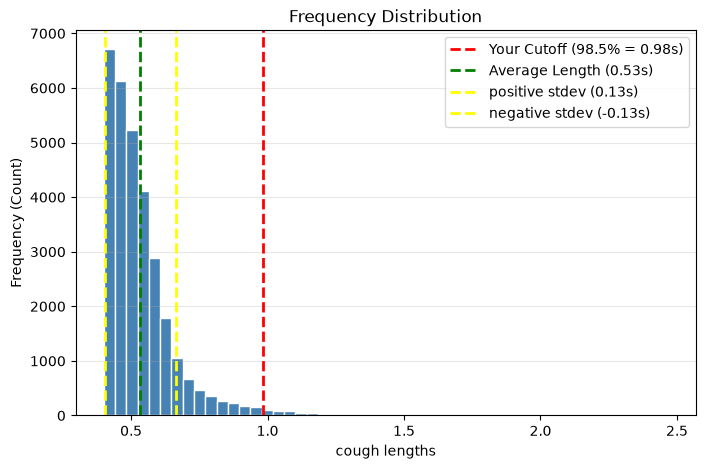

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Use 'edgecolor' to visually separate the bars cleanly
plt.hist(results, bins=50, color="#4682B4", edgecolor="white")

plt.xlabel("cough lengths")
plt.ylabel("Frequency (Count)")
plt.title("Frequency Distribution")
plt.grid(axis='y', alpha=0.3)  # Clean, minimal grid lines on the y-axis only
plt.axvline(target_len_98_5, color='red', linestyle='--', linewidth=2, label=f'Your Cutoff ({98.5}% = {target_len_98_5:.2f}s)')
plt.axvline(avg, color='green', linestyle='--', linewidth=2, label=f'Average Length ({avg:.2f}s)')
plt.axvline(avg+std, color='yellow', linestyle='--', linewidth=2, label=f'positive stdev ({std:.2f}s)')
plt.axvline(avg-std, color='yellow', linestyle='--', linewidth=2, label=f'negative stdev ({-std:.2f}s)')
plt.legend()
plt.show()

#### due to how rightly skewed we will use a 95 and 98.5 percentile.
#### due to wanting to use a whole number we will use the 98.5 percentile and round it to 1.0s. this allows most of the dataset to be shown and gets a good bit of the longer samples